<a href="https://colab.research.google.com/github/maciekpopik/ENEN-645-Group-4-Final/blob/main/PlantLab2RealGeneralization_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [13]:
#Dataset Paths

DATASET_ROOT = "/content/drive/MyDrive/PlantLab2RealGeneralization"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
VAL_DIR   = os.path.join(DATASET_ROOT, "Val")
TEST_DIR  = os.path.join(DATASET_ROOT, "Test_ID")

In [14]:
#Parameters

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2


In [15]:
#Train transforms (data augmentation + normalization)


train_transforms = transforms.Compose([

  # Cropping (breaks static background bias)
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.5, 1.0),    # strong zoom & spatial variability
        ratio=(0.75, 1.33)
    ),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),

    # Color / Lighting Variability
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.35,
        saturation=0.4,
        hue=0.08
    ),

    transforms.ToTensor(),

    # Normalization (ImageNet-pretrained models)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [16]:
#Evaluate transforms (no agumentation)

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [17]:
#Datasets

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=eval_transforms
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transforms
)



In [18]:
#Dataloaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)


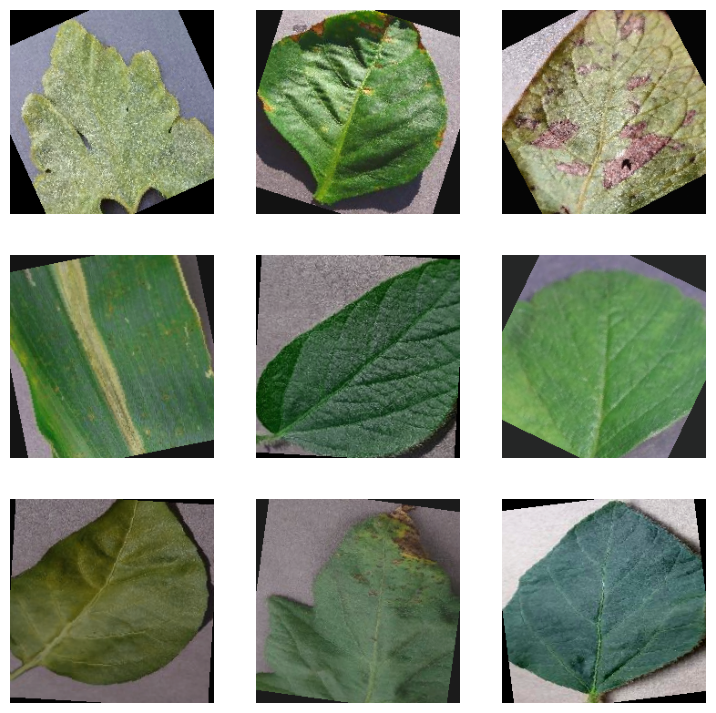

In [19]:
#Sanity check

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(9,9))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    img = images[i].permute(1,2,0)
    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])
    plt.imshow(img.clamp(0,1))
    plt.axis("off")
plt.show()
